## Introduction

Netflix, a leading global streaming platform, hosts a vast library of movies and TV shows. This project conducts a Python-based analysis of Netflix's content data for the year 2021-2022 to understand the platform's content strategy.

## Project Objectives

The primary goal is to analyze distribution trends across different content types, regions, and ratings. Through data wrangling and visualization, this project aims to derive actionable insights into Netflix's growth patterns and content evolution

### Data Loading and Initial Inspection

In this section, we load the Netflix dataset into our environment to begin the analysis. We will import the necessary libraries and access the data to examine its initial structure, including column names and the first few rows, to ensure the file is ready for processing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
df.head() # shows first five rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info() # shows summary of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
df.isnull().sum() #check for missing values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

The data has been successfully loaded and inspected, confirming that the structure is ready for preprocessing. We will now proceed to the data cleaning phase to address the identified issues.

### Data Cleaning (Wrangling)

We will now address the missing values identified during the initial inspection. This process involves filling missing entries in the 'director', 'cast', and 'country' columns with 'Unknown' and removing rows with insufficient data to ensure the dataset is refined for accurate analysis.

In [4]:
df['director'] = df['director'].fillna('unknown')# fill missing values with unknown
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown',)

df.dropna(inplace=True) # drop row with missing values
df.isnull().sum() # verify that missing values are handled

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [5]:
print(df.dtypes) # check data types of each column

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [6]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())#to_datetime--> func that convert columns into datetime format # str.strp-->remove extra spaces in dates
print(df[['date_added']].dtypes) # it change text to real date format

date_added    datetime64[ns]
dtype: object


In [7]:
df.duplicated().sum()# check for duplicate rows

np.int64(0)

### Exploratory Data Analysis (EDA)

With the data cleaning and wrangling process successfully finalized, the dataset is now refined and ready for exploration. In this section, we will systematically visualize the underlying trends and distribution patterns to identify significant insights from Netflix's content library and its growth over time.

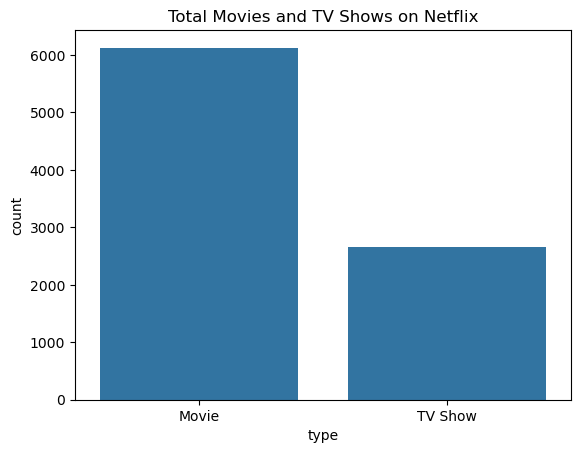

In [8]:
df['year_added'] = df['date_added'].dt.year# make new column for year that extract only year from data # dt-->datetime accessor of pandas
sns.countplot(x='type',data=df)
plt.title('Total Movies and TV Shows on Netflix')
plt.show()      
# checking if netflix has more movies or TV shows

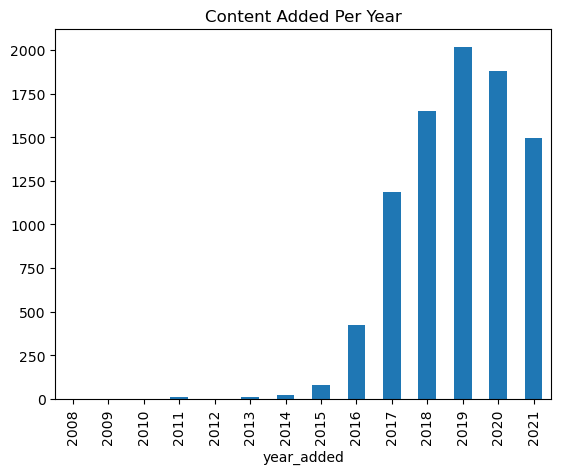

In [9]:
df['year_added'].value_counts().sort_index().plot(kind='bar')
plt.title('Content Added Per Year')
plt.show()

#### Analysis of Content Added Per Year

Content releases were minimal until 2016, followed by a sharp, exponential growth that peaked in 2019, clearly indicating the platform's rapid global expansion phase.

In [10]:
df=df[df['country'] !='unknown']
df['country'].value_counts().head(10)# head(10)-->shows onlt top 10 countaries with highest count

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

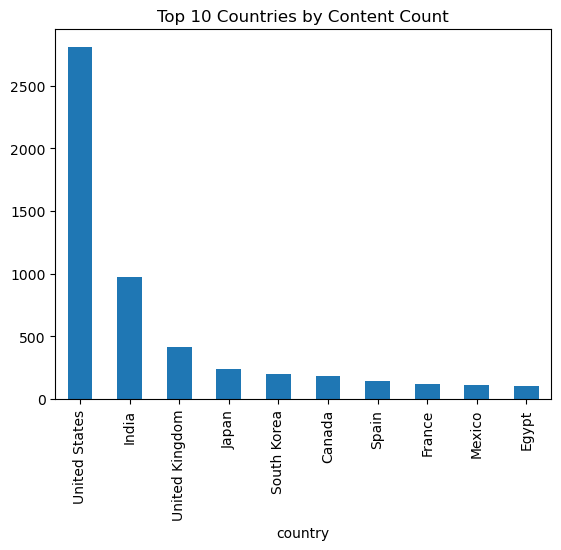

In [11]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries by Content Count')
plt.show()

#### Top 10 Countries by Content Production:

The United States is the leading producer of content, followed by India and the United Kingdom, which highlights the platform's focus on major global markets.

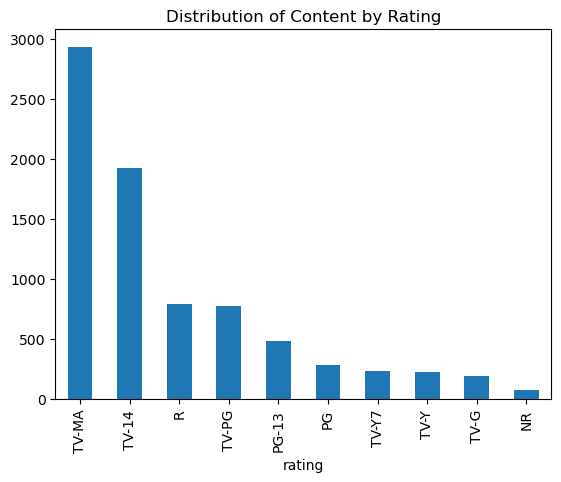

In [12]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title('Distribution of Content by Rating')
plt.show()

#### Distribution of Content by Rating:

The highest volume of content is rated TV-MA and TV-14, which indicates that the platform primarily caters to mature audiences and teenagers

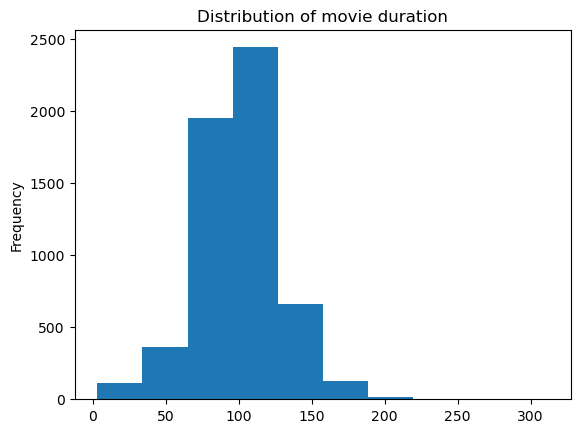

In [13]:
movies=df[df['type'] == 'Movie'].copy()
movies['duration']=movies['duration'].str.replace('min','').astype(int)
movies['duration'].plot(kind='hist')
plt.title('Distribution of movie duration')
plt.show()

#### Distribution of Movie Duration:

Most movies fall in the 75-125 minute range, showing that the platform focuses on standard-length feature films for optimal viewer engagement.

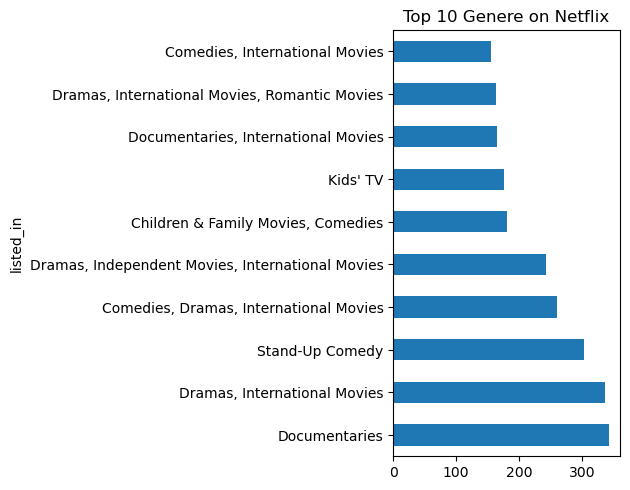

In [14]:
df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.tight_layout()
plt.title('Top 10 Genere on Netflix')
plt.show()

#### Top 10 Generes on the Platform:

Documentaries and International Movies are the most popular generes, indicating that viewers have a strong preference for non-fiction and diverse global content

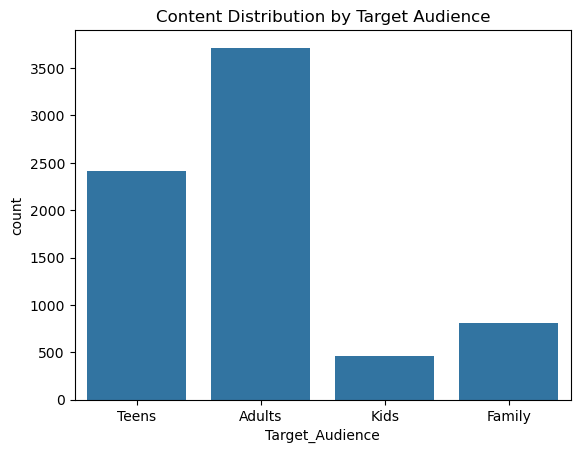

In [15]:
audience_map = {
    'TV-MA':'Adults','R':'Adults','TV-14':'Teens','PG-13':'Teens','TV-PG':'Family','G':'Family','TV-Y':'Kids','TV-Y7':'Kids'
}
df['Target_Audience']=df['rating'].map(audience_map)# Apply the mapping to create a new 'Target_Audience' column
sns.countplot(x='Target_Audience',data=df)
plt.title('Content Distribution by Target Audience')
plt.show()

#### Target Audience Analysis

As seen in the chart, the majority of Netflix content is targeted toward Adults, indicating a niche focus on mature audiences.

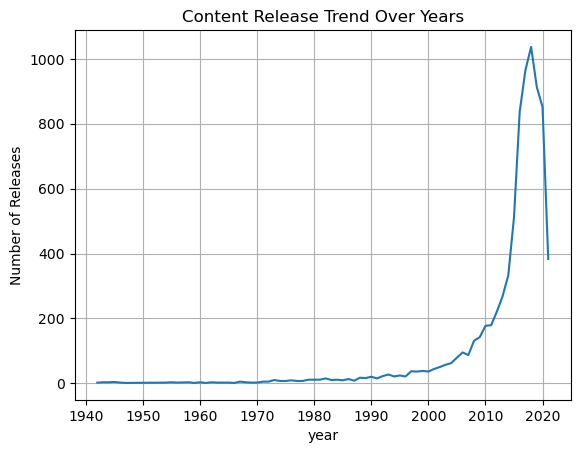

In [16]:
yearly_trend=df['release_year'].value_counts().sort_index()
yearly_trend.plot(kind='line')
plt.xlabel('year')
plt.ylabel('Number of Releases')
plt.title('Content Release Trend Over Years')
plt.grid(True)
plt.show()

#### Yearly Content Analysis

The data shows a significant surge in content releases over the last decade, indicating Netflix's aggressive expansion strategy to capture the global market.

## Conclusion & Strategic Insights

#### Platform Growth Trends: 
The data analysis confirms a period of exponential growth in content production between 2016 and 2020, reflecting Netflix’s aggressive global expansion and content acquisition strategy.

#### Targeted Content Strategy: 
The dominance of 'TV-MA' and 'TV-14' ratings indicates that Netflix primarily curates content tailored for mature audiences and teenagers to maximize viewer engagement.

#### Global Positioning: 
The leading position of the United States, followed by significant contributions from India and the UK, underscores the platform's successful transition into a global content powerhouse.

#### Future Business Value: 
Integrating viewer ratings and sentiment analysis in future iterations could further optimize recommendation engines, leading to improved user retention and personalized content delivery.

## Recommendation & Future Scope

#### Future Scope: 
To deepen this analysis, integrating 'Watch-time' or 'User Engagement' metrics would provide more precise insights into content popularity than simple release counts alone.

#### Key Suggestions: 
Netflix should diversify its library by increasing 'Family-Oriented' programming and expanding 'Non-English' content production to better reach untapped global market segments
